<a href="https://colab.research.google.com/github/JoseCarmona17/Bit-Data_Science/blob/main/act8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# Carga y exploración de los datos del df

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv('/content/sample_data/insurance.csv')

In [33]:
# Exploración básica

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


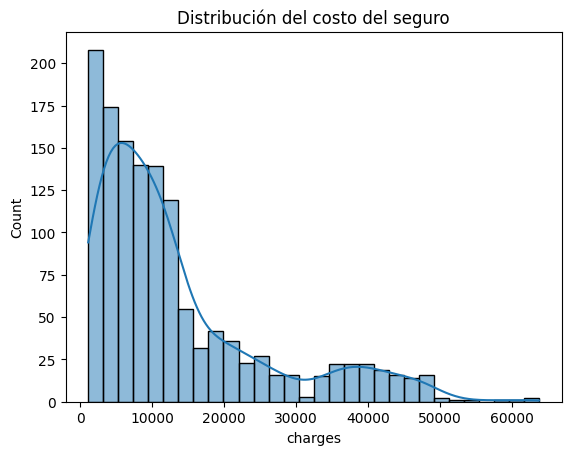

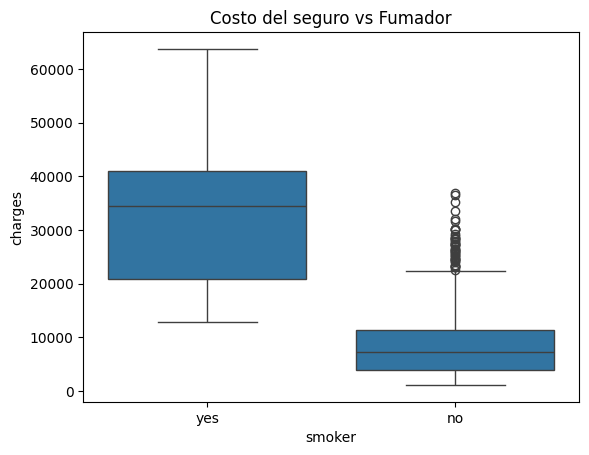

In [34]:
# Histograma para analizar la distribución del costo del seguro y su densidad
sns.histplot(df["charges"], kde=True)
plt.title("Distribución del costo del seguro")
plt.show()

# Boxplot para comparar el costo del seguro entre fumadores y no fumadores
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Costo del seguro vs Fumador")
plt.show()

los fumadores tienen costos mucho más altos

In [35]:
# Convierte las variables categóricas en variables numéricas usando one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

In [36]:
# Separa las variables independientes (X) y la variable objetivo (y)
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]


In [37]:
# Divide los datos en conjuntos de entrenamiento y prueba (80% / 20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
# Escala las variables numéricas para mejorar el rendimiento del modelo
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Modelos a entrenar y comparar**

In [39]:
# Modelo 1: Entrena un modelo de regresión lineal y realiza predicciones
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [40]:
#  Modelo 2: Entrena un modelo Random Forest para predecir el costo del seguro
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [41]:
# Modelo 3: Entrena un modelo Gradient Boosting para la predicción del costo del seguro
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [42]:
# Función para evaluar el rendimiento del modelo usando MAE, RMSE y R²
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluar(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    return mae, rmse, r2



In [43]:
# Crea un DataFrame para comparar el rendimiento de los modelos evaluados
resultados = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Random Forest", "Gradient Boosting"],
    "MAE": [
        evaluar(y_test, y_pred_lr)[0],
        evaluar(y_test, y_pred_rf)[0],
        evaluar(y_test, y_pred_gb)[0]
    ],
    "RMSE": [
        evaluar(y_test, y_pred_lr)[1],
        evaluar(y_test, y_pred_rf)[1],
        evaluar(y_test, y_pred_gb)[1]
    ],
    "R2": [
        evaluar(y_test, y_pred_lr)[2],
        evaluar(y_test, y_pred_rf)[2],
        evaluar(y_test, y_pred_gb)[2]
    ]
})

resultados



,Modelo,MAE,RMSE,R2
0,Regresión Lineal,4181.194474,5796.284659,0.783593
1,Random Forest,2550.078471,4576.299916,0.865103
2,Gradient Boosting,2443.483262,4329.570011,0.879257


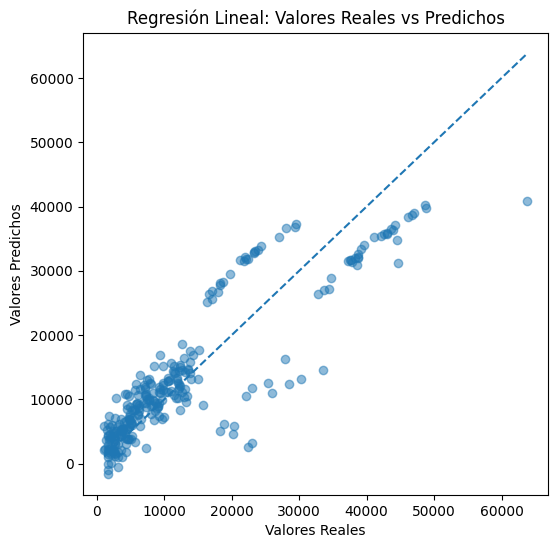

In [44]:
# Gráfica – Regresión Lineal

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.title("Regresión Lineal: Valores Reales vs Predichos")
plt.show()


**Aquí observamos:**


*   Mayor dispersión de puntos
*   El modelo subestima y sobreestima valores altos

*   No captura bien relaciones no lineales





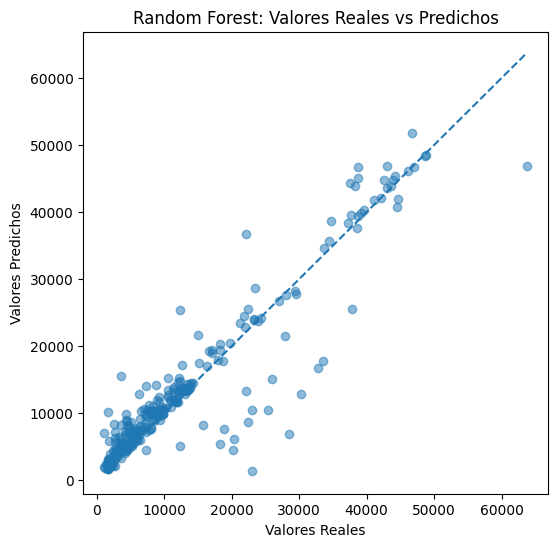

In [45]:
# Gráfica – Random Forest Regressor

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.title("Random Forest: Valores Reales vs Predichos")
plt.show()



**Aquí observamos:**



*   Puntos mucho más cercanos a la diagonal
*   Menor dispersión
*   Mejor ajuste general
*   Maneja bien relaciones complejas





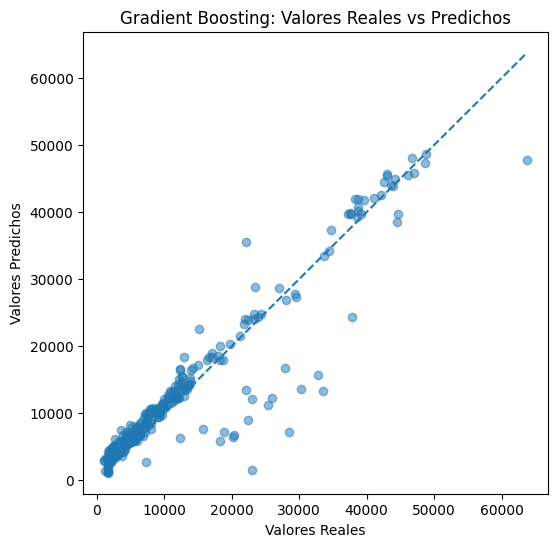

In [46]:
# Gráfica – Gradient Boosting Regressor

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_gb, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.title("Gradient Boosting: Valores Reales vs Predichos")
plt.show()



**Aquí observamos:**



*   Ajuste muy preciso
*   Mejor comportamiento en valores extremos
*   Menos ruido que la regresión lineal



Al comparar las gráficas de valores reales vs predichos, se observa que la Regresión Lineal presenta mayor dispersión, lo que indica una menor capacidad predictiva.
Por otro lado, Random Forest y Gradient Boosting muestran una mayor concentración de puntos alrededor de la línea diagonal.
Entre estos dos, Random Forest presenta el mejor equilibrio entre precisión y estabilidad, lo que se refleja tanto en las métricas como en la visualización.

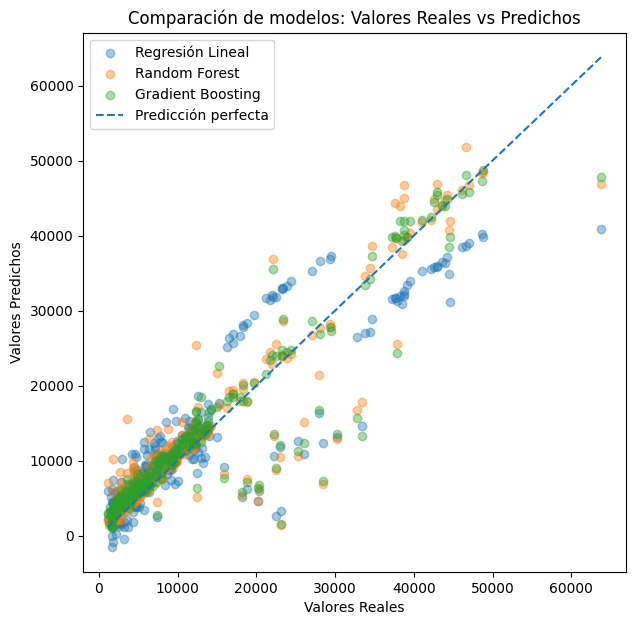

In [47]:
# grafica unificada de los diferentes modelos

plt.figure(figsize=(7,7))

# Regresión Lineal
plt.scatter(
    y_test, y_pred_lr,
    alpha=0.4,
    label="Regresión Lineal"
)

# Random Forest
plt.scatter(
    y_test, y_pred_rf,
    alpha=0.4,
    label="Random Forest"
)

# Gradient Boosting
plt.scatter(
    y_test, y_pred_gb,
    alpha=0.4,
    label="Gradient Boosting"
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.title("Comparación de modelos: Valores Reales vs Predichos")
plt.legend()
plt.show()


En la gráfica comparativa se observa que la Regresión Lineal presenta mayor dispersión respecto a la línea de predicción perfecta, lo que indica un menor ajuste del modelo.
Random Forest y Gradient Boosting muestran una mayor concentración de puntos alrededor de la diagonal, evidenciando un mejor desempeño predictivo.
Entre estos, Random Forest presenta una dispersión ligeramente menor, lo que confirma los resultados obtenidos en las métricas de evaluación.

**Conclusión**

---

Se aplicaron tres modelos de regresión para predecir el costo del seguro médico.
La Regresión Lineal mostró un desempeño aceptable, pero limitado al no capturar relaciones no lineales.
Random Forest y Gradient Boosting obtuvieron mejores métricas, siendo Random Forest el modelo con mayor R² y menor error.
Se evidenció que la variable smoker tiene un impacto significativo en el costo del seguro.
En conclusión, los modelos basados en árboles ofrecen mejores resultados para este problema.